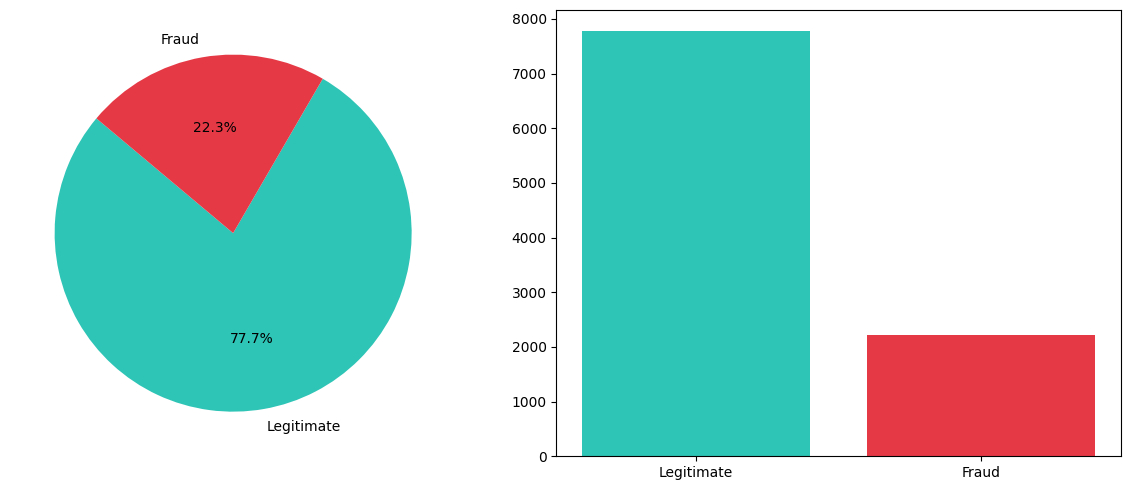

In [3]:
import pandas as pd, matplotlib.pyplot as plt
import seaborn as sns        # sns comes from here
import pandas as pd  

acc = pd.read_csv('account_data.csv')
counts = acc['IsFraud'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(counts, labels=['Legitimate','Fraud'],
            colors=['#2EC4B6','#E63946'],
            autopct='%1.1f%%', startangle=140)
axes[1].bar(['Legitimate','Fraud'], counts.values,
            color=['#2EC4B6','#E63946'])
plt.tight_layout()

{'whiskers': [<matplotlib.lines.Line2D at 0x2100653f810>,
 'caps': [<matplotlib.lines.Line2D at 0x2107ff05910>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2107fea8f90>,
 'medians': [<matplotlib.lines.Line2D at 0x2107ff0ca50>,
 'fliers': [<matplotlib.lines.Line2D at 0x210060e1490>,
 'means': []}

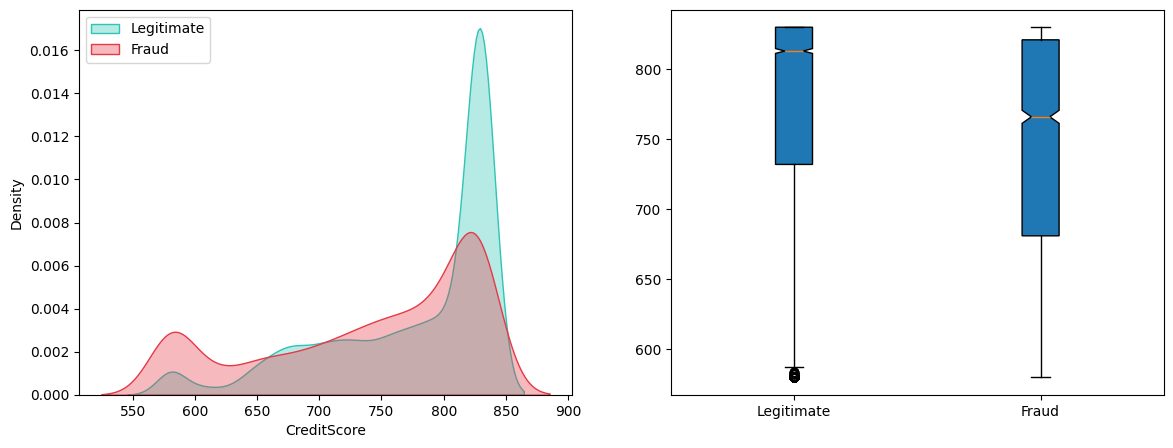

In [9]:
fraud = acc[acc['IsFraud']=='Yes']['CreditScore']
legit = acc[acc['IsFraud']=='No']['CreditScore']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.kdeplot(legit, ax=axes[0], color='#2EC4B6',
            fill=True, alpha=0.35, label='Legitimate')
sns.kdeplot(fraud, ax=axes[0], color='#E63946',
            fill=True, alpha=0.35, label='Fraud')
axes[0].legend()
axes[1].boxplot([legit.values, fraud.values],
                tick_labels=['Legitimate','Fraud'],
                notch=True, patch_artist=True)

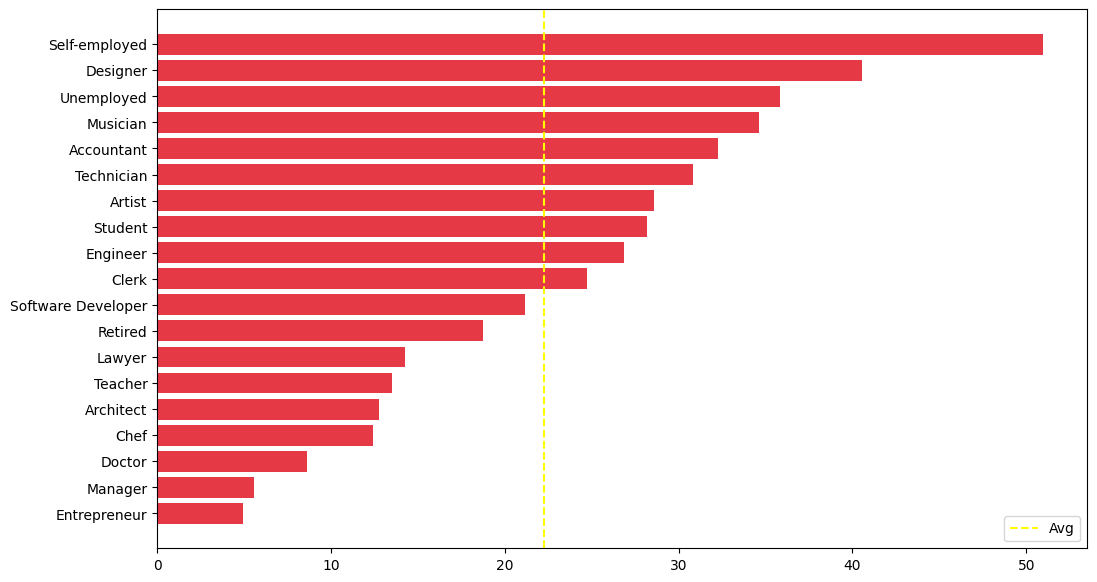

In [10]:
acc['FraudFlag'] = (acc['IsFraud']=='Yes').astype(int)
occ_fraud = (
    acc.groupby('Occupation')['FraudFlag']
    .agg(FraudRate=lambda x: x.mean()*100)
    .sort_values('FraudRate', ascending=True)
    .reset_index()
)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(occ_fraud['Occupation'],
        occ_fraud['FraudRate'], color='#E63946')
ax.axvline(acc['FraudFlag'].mean()*100,
           color='yellow', linestyle='--', label='Avg')
ax.legend()

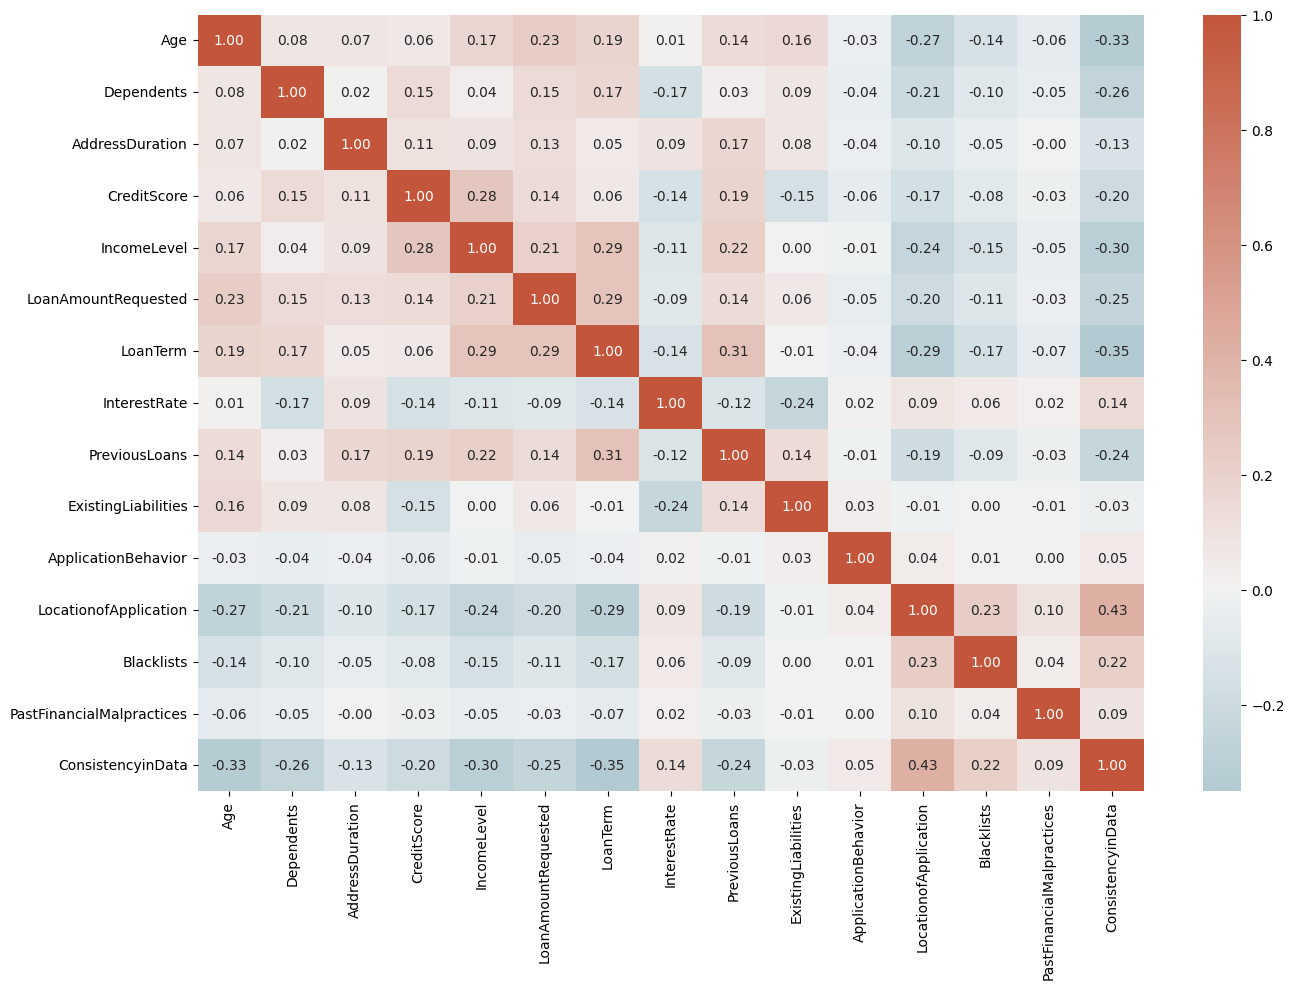

In [5]:
acc = pd.read_csv('account_data.csv')
encode_map = {
    'ApplicationBehavior':       {'Normal':0,'Rapid':1},
    'LocationofApplication':     {'Local':0,'Unusual':1},
    'Blacklists':                {'No':0,'Yes':1},
    'PastFinancialMalpractices': {'No':0,'Yes':1},
    'ConsistencyinData':         {'Consistent':0,'Inconsistent':1},
}
heat_df = acc.copy()
for col, mapping in encode_map.items():
    heat_df[col] = heat_df[col].map(mapping)

numeric_cols = heat_df.select_dtypes(include='number').columns.tolist()
corr = heat_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))  # adjust (width, height) in inches
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap=sns.diverging_palette(220,20,as_cmap=True),
            center=0)
plt.tight_layout()
plt.show()

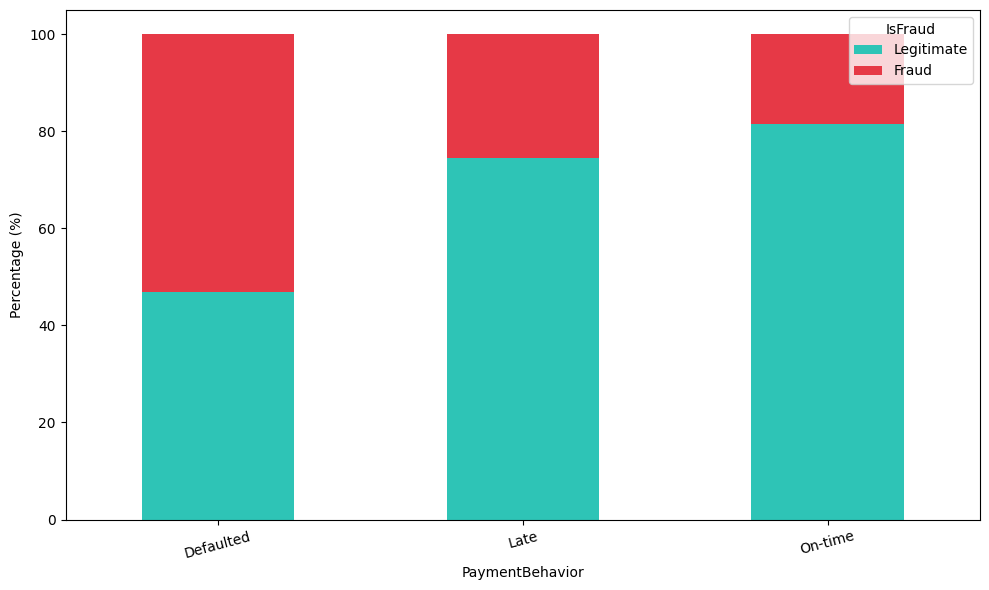

In [6]:
pay_cross = pd.crosstab(
    acc['PaymentBehavior'],
    acc['IsFraud'],
    normalize='index'
) * 100
pay_cross = pay_cross.rename(
    columns={'No':'Legitimate','Yes':'Fraud'})
pay_cross.plot(kind='bar', stacked=True,
               color=['#2EC4B6','#E63946'],
               figsize=(10, 6))
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.tight_layout()

int64
[0 1]


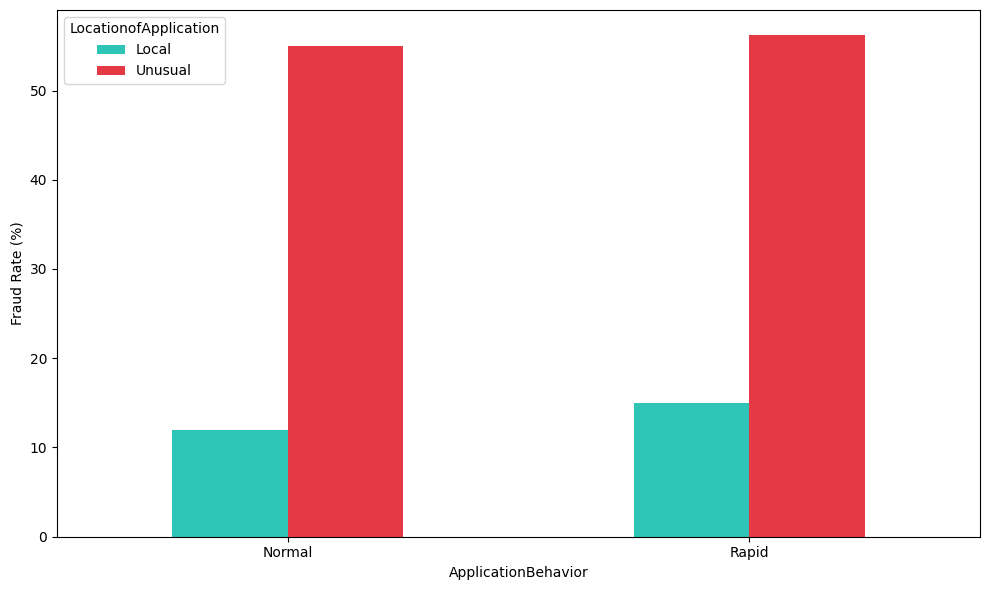

In [9]:
# Step 1: Convert IsFraud to numeric IN acc
acc['IsFraud'] = acc['IsFraud'].map({'No': 0, 'Yes': 1})

# Step 2: Verify it worked
print(acc['IsFraud'].dtype)      # should print int64
print(acc['IsFraud'].unique())   # should print [0, 1]

# Step 3: Now run the groupby
combo = acc.groupby(
    ['ApplicationBehavior', 'LocationofApplication']
)['IsFraud'].mean().reset_index()

combo['FraudRate'] = combo['IsFraud'] * 100

pivot = combo.pivot(
    index='ApplicationBehavior',
    columns='LocationofApplication',
    values='FraudRate')

pivot.plot(kind='bar', figsize=(10, 6),
           color=['#2EC4B6', '#E63946'])
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()